### Analysing Dataset

* Dataset-Path: `../Dataset/dataset.parquet`
* Dataset, (Downloaded from kaggle): [CIC-IDS2017 Dataset](https://www.kaggle.com/datasets/dhoogla/cicids2017)

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

sns.set_style('whitegrid')

In [2]:
DATA_PATH = "../Dataset/dataset.parquet"

In [3]:
df = pd.read_parquet(DATA_PATH, engine='pyarrow')

df.sample(5)

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
461094,17,23981,2,2,70,102,35,35,35.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign
765890,6,5522847,8,11,883,4555,566,0,110.375000,198.296997,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
155377,6,6168331,15,14,1280,3096,517,0,85.333336,150.316650,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1308111,6,5946748,5,1,123,46,46,0,24.600000,23.276598,...,32,15191.0,0.0,15191,15191,5889503.0,0.0,5889503,5889503,Benign
1223432,17,206,2,2,76,300,38,38,38.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign


In [4]:
df.shape

(2313810, 78)

In [5]:
df.columns = df.columns.map(lambda x: x.lower())

In [6]:
df["label"].value_counts()

label
Benign                        1977318
DoS Hulk                       172846
DDoS                           128014
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
PortScan                         1956
Web Attack � Brute Force         1470
Bot                              1437
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

#### Dataset Restructuring and Cleaning

* There are multiple features and labels in the dataset, also it contains about 2.3 million rows.

* We will be randomly sampling 100,000 rows and select only useful features for model training and evaluation

In [7]:
features = [
    'flow iat mean', 'flow iat std', 'idle mean', 'flow duration',
    'packet length mean', 'packet length std', 'avg packet size',
    'total fwd packets', 'total backward packets', 'fwd iat total',
    'down/up ratio', 'protocol'
]

In [8]:
df_benign = df[df["label"] == "Benign"]
df_malicious = df[df["label"] != "Benign"]

In [9]:
df_malicious.shape, df_benign.shape

((336492, 78), (1977318, 78))

In [10]:
df_malicious["new_label"] = "Malicious"

C:\Users\Sangam\AppData\Local\Temp\ipykernel_31052\2782122487.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_malicious["new_label"] = "Malicious"


#### Plotting dataset distribution

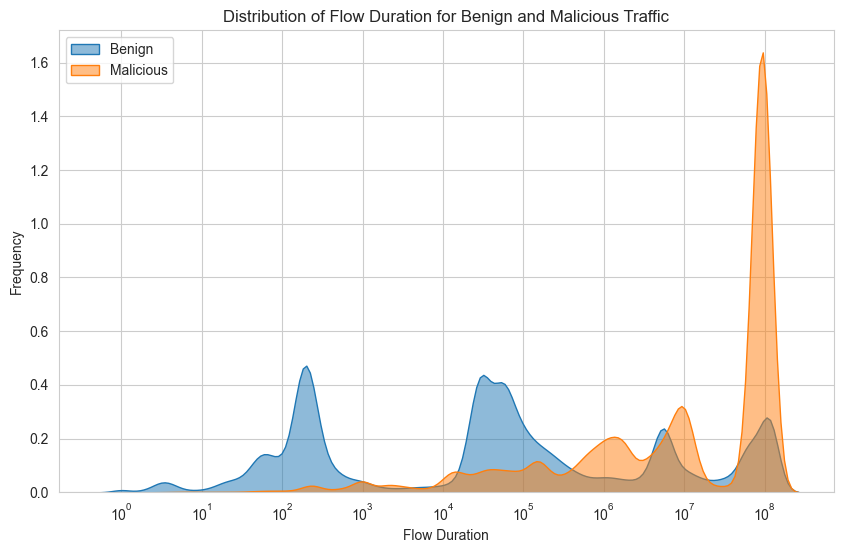

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.kdeplot(df_benign["flow duration"], label="Benign", ax=ax, fill=True, alpha=0.5, common_norm=False, log_scale=True)
sns.kdeplot(df_malicious["flow duration"], label="Malicious", ax=ax, fill=True, alpha=0.5, common_norm=False, log_scale=True)
ax.set_title("Distribution of Flow Duration for Benign and Malicious Traffic")
ax.set_xlabel("Flow Duration")
ax.set_ylabel("Frequency")
ax.legend()
plt.show()

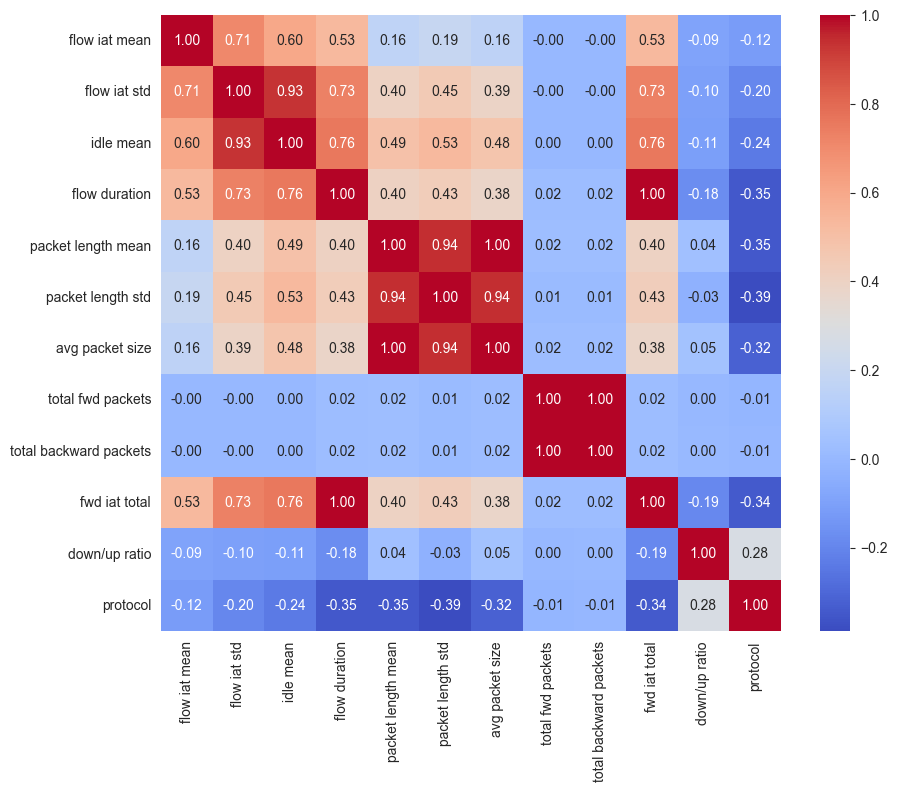

In [15]:
corr = df[features].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

In [18]:
temp_df = df.copy()

temp_df["label"] = temp_df["label"].apply(lambda x: "Benign" if x == "Benign" else "Malicious")

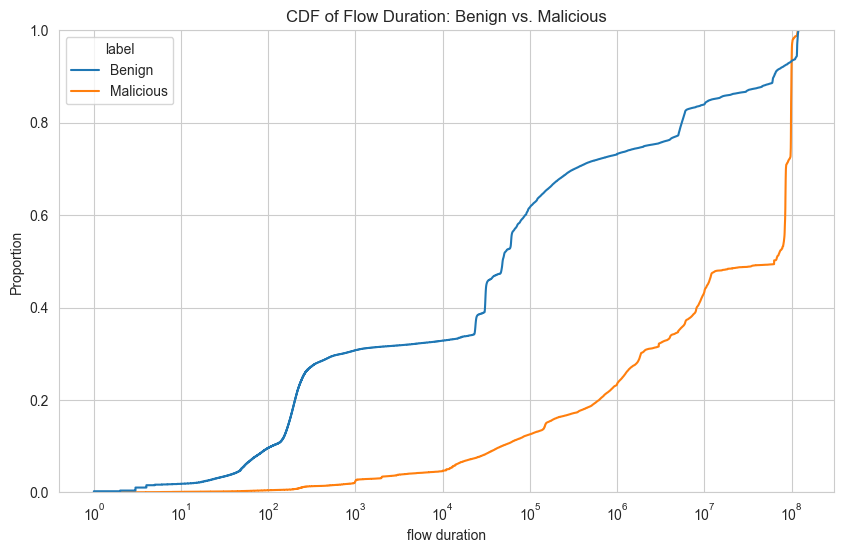

In [20]:
plt.figure(figsize=(10, 6))

sns.ecdfplot(data=temp_df, x='flow duration', hue='label', log_scale=True)
plt.title("CDF of Flow Duration: Benign vs. Malicious")
plt.show()

#### Verdict

1. * **Mathematical Validation of Features Temporal Dominance**: The Flow Duration CDF reveals a "heavy-tail" distribution for malicious actors. While $80\%$ of benign traffic completes in under $10^6\mu s$, over $50\%$ of malicious traffic (specifically DoS and Bots) pins connections for $10^8\mu s$, suggesting a programmatic "hold" on server resources.
   * **The Periodicity Signal**: Initial variance analysis shows that Flow IAT Std is a primary "snitch". Benign traffic is "bursty" (high variance), whereas automated scripts exhibit lower, more rigid variance or artificially high jitter.

2. * **Dimensionality Reduction & Optimization Multicollinearity Identified**: The correlation heatmap reveals extreme redundancy ($r > 0.95$) between packet length mean, avg packet size, and fwd iat total.
   * **Engineering Decision**: To optimize the future Go/Redis middleware, I will prune the feature set from 78 down to the 12 most uncorrelated behavioral features. This reduces the computational complexity of the Isolation Forest from $O(n \cdot 78)$ to $O(n \cdot 12)$, significantly lowering inference latency.

3. * **Strategy for Modeling Baseline Failure**: Simple linear thresholds (e.g., $Req/Sec$) will fail to capture the "Low-and-Slow" bots observed in the $10^4$ to $10^6$ duration range where they overlap with human activity.
   * **Final Choice**: An unsupervised Isolation Forest trained exclusively on Benign traffic is the optimal path. It will isolate the "structural outliers" found in the CDF peaks without requiring a labeled attack history.